# Scikit-Learn Spectral Clustering with NVIDIA cuML

### Notebook Outline
**Section 1**  
 - Spectral Clustering in Quantitative Research  

**Section 2** 
 - Data Preparation
 - Sample Use-Case - Equities-Options Risk Surfaces function
 - CPU Execution  

**Section 3** 
 - GPU Accelerated Scikit-Learn: NVIDIA cuML
 - GPU Execution (results, runtime)
 - code profiling
 - GPU v CPU: results and runtimes  

**Section 4**
 - Visualizations: 2D and 3D  

**Section 5**
 - Benchmarking Scikit-Learn Spectral Clustering CPU v GPU  
 - Benchmarking Visuals

**Section 6**
 - Next Steps

**Section 6**

**TL;DR — Run `%load_ext cuml.accel` before your sklearn imports and `sklearn.cluster.SpectralClustering` runs on your NVIDIA GPU.**

The rendering of this notebook is from running the notebook an a Threadripper PRO 7965WX with an RTX PRO 6000 Blackwell.  
Expect the largest scenario to land in the 100–150× range and the maximum speedup overall to land in the 200–250× range.

---

## What this notebook is and isn't

This notebook **is** a Scikit-Learn Spectral Clustering benchmark using a recognizable feature space (an equity-options vol surface). The notebook compares results and measures runtimes, not investment skill.

This notebook **is not:**

- **A vol-trading strategy.** The data is a single-day cross-sectional snapshot from 2026-04-16. There is no walk-forward, no out-of-sample window, no transaction-cost model. Don't trade off this notebook, it is for educational purposes.
- **A claim that GPU and CPU produce bit-identical labels.** The eigensolvers and k-NN graph construction differ algorithmically. Section 9 measures structural agreement (ARI/NMI), which is the relevant correctness check for clustering.
- **Hardware-portable.** Numbers saved in the Github notebook are specific to a Threadripper PRO 7965WX (24 cores) and an RTX PRO 6000 Blackwell. Different hardware will produce different ratios.

---

## Install NVIDIA cuML and NVIDIA cuDF

```bash
# uv (recommended)
uv pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13

# pip
pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13

```

Requirements: an NVIDIA GPU with CUDA 12+ and a recent driver.  
If using __CUDA 12__, change the above dependencies to __cuml-cu12 cudf-cu12__



## Hardware Detection

In [1]:
!lscpu | grep -E "^Model name|^CPU\(s\):|^Thread|^Socket" | sed 's/  */ /g'

CPU(s): 48
Model name: AMD Ryzen Threadripper PRO 7965WX 24-Cores
Thread(s) per core: 2
Socket(s): 1


In [2]:
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv,noheader

NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 580.105.08, 97887 MiB


In [3]:
import platform
import sklearn
import pandas
import scipy
import numpy

print(f"Python:   {platform.python_version()}")
print(f"Platform: {platform.platform()}")
print(f"sklearn:  {sklearn.__version__}")
print(f"scipy:    {scipy.__version__}")
print(f"numpy:    {numpy.__version__}")
print(f"pandas:   {pandas.__version__}")

Python:   3.12.3
Platform: Linux-6.8.0-106-generic-x86_64-with-glibc2.39
sklearn:  1.8.0
scipy:    1.17.1
numpy:    2.4.6
pandas:   2.3.3


---

# 1. Spectral Clustering in Quantitative Research


Spectral clustering is gaining traction in quantitative research. Here are some recent publications applying spectral clustering for 
* volatility regime detection
* market structure discovery
* asset clustering
  
---
  
 * **Improving S&P 500 Volatility Forecasting through Regime-Switching Methods**   
    * Ava C. Blake, Nivika A. Gandhi, Anurag R. Jakkula, Sep 2025
    * https://arxiv.org/abs/2510.03236

* **Longitudinal market structure detection using a dynamic modularity-spectral algorithm**
    * Philipp Wirth, Francesca Medda, Thomas Schröder, Jul 2024
    * https://arxiv.org/abs/2407.04500

* **Structural clustering of volatility regimes for dynamic trading strategies**
    * Arjun Prakash, Nick James, Max Menzies, Gilad Francis, Nov 2021
    * https://arxiv.org/abs/2004.09963

* **Regularized spectral methods for clustering signed networks**
    * Mihai Cucuringu, Apoorv Vikram Singh, Déborah Sulem, Hemant Tyagi, Nov, 2020
    * https://arxiv.org/abs/2011.01737

* **SPONGE: A generalized eigenproblem for clustering signed networks**
    * Mihai Cucuringu, Peter Davies, Aldo Glielmo, Hemant Tyagi, May, 2019
    * https://arxiv.org/abs/1904.08575

  
Related Machine Learning research on spectral clustering:

* **Advanced spectral clustering for heterogeneous data in credit risk monitoring systems**
    * Lu Han, Mengyan Li, Jiping Qiang, Zhi Su, Aug 2025
    * https://arxiv.org/abs/2509.00546 

* **A Wasserstein distance-based spectral clustering method for transaction data analysis**
    * Yingqiu Zhu, Danyang Huang, Bo Zhang, Jan 2025
    * https://www.sciencedirect.com/science/article/abs/pii/S0957417424022851

* **Quantifying uncertainty in spectral clusterings: expectations for perturbed and incomplete data**
    * Jürgen Dölz, Jolanda Weygandt, May 2025
    * https://arxiv.org/abs/2505.17819
  
  
    
This notebook uses options-surface data as a concrete benchmark for CPU vs GPU performance, but the speedup applies broadly. Spectral clustering's bottleneck is the eigendecomposition of the affinity matrix, which is independent of how that matrix was constructed.

---

# 2. Benchmark Workload - Equities-Options Feature Space

This notebook needs a feature space that is (a) recognizable to a quant, (b) high-dimensional enough that the eigensolver is the bottleneck, and (c) large enough to stress the CPU and GPU. An options-surface snapshot with Greeks fits all three. This is the benchmark workload, not a trading strategy. This workload and notebook are for educational purposes. Spectral Clustering at k=30 also helps provide a workload that showcases the demands of a CPU and GPU. A full benchmark with varying parameters is in Section 5.

In this section we:
1. Build the feature matrix from ~54K equity-options contracts
2. Define a single self-contained `cluster_options()` function
3. Run `cluster_options()` on the CPU. 

### 2.1 Load Options Data, Compute Black-Scholes Greeks, Build Feature Matrix X

**The data:** 
* ~54K US equity-options contracts
* pulled from yfinance on **2026-04-16** 
* 20 underliers
* filtered for `IV > 0.01`, `T > 1 day`, positive `spot` and `strike`.

**Features (8 columns):** 
* log(strike/spot) - log-moneyness
* sqrt(T_years) - vol-time
* log(IV) - log implied volatility
* is_call - call/put indicator
* delta, gamma, vega, theta - Black-Scholes Greeks
  
The features are standardized with `sklearn.preprocessing.StandardScaler`.

To simplify assumptions on rates and dividends a flat risk-free rate `r = 0.04` and zero dividend yield `q = 0.0` are used for every contract. Production code would use the OIS curve at each tenor and per-ticker dividend yields. The bias is monotonic in S, T, and q so the relative cluster geometry is preserved.

Sufrace coordinates references:
* **<i>The Volatility Surface: A Practitioner's Guide</i>**, Gatheral (2006), Wiley Finance  
* <i>Arbitrage-free SVI volatility surfaces</i>, Quantitative Finance, Gatheral & Jacquier (2014) https://arxiv.org/abs/1204.0646

In [4]:
import glob
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

files = sorted(glob.glob("data/*.parquet"))
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

df["expiration"] = pd.to_datetime(df["expiration"])
df["fetched_at"] = pd.to_datetime(df["fetched_at"]).dt.tz_localize(None)
df["T_years"] = (df["expiration"] - df["fetched_at"]).dt.total_seconds() / (365.0 * 24 * 3600)

df = df[
    (df["impliedVolatility"] > 0.01)
    & (df["T_years"] > 1 / 365)
    & (df["spot"] > 0)
    & (df["strike"] > 0)
].reset_index(drop=True)

print(f"contracts: {len(df):,}")
print(f"underliers: {df['underlying'].nunique()}")
print(f"tenor range: {df['T_years'].min():.3f} to {df['T_years'].max():.2f} years")
print(f"IV range:   {df['impliedVolatility'].min():.3f} to {df['impliedVolatility'].max():.2f}")

contracts: 54,385
underliers: 20
tenor range: 0.009 to 2.67 years
IV range:   0.016 to 22.25


In [5]:
# Black-Scholes Greeks, vectorized over the full DataFrame.
# r = 0.04, q = 0.0 — reasonable defaults for short-dated US single-name options.
S = df["spot"].to_numpy()
K = df["strike"].to_numpy()
T = df["T_years"].to_numpy()
sigma = df["impliedVolatility"].to_numpy()
is_call = (df["option_type"] == "call").to_numpy()

r, q = 0.04, 0.0

sqrtT = np.sqrt(T)
d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
d2 = d1 - sigma * sqrtT

pdf_d1 = norm.pdf(d1)
disc_q = np.exp(-q * T)
disc_r = np.exp(-r * T)

# Delta: directional exposure; flips sign for puts.
delta = np.where(is_call,
                 disc_q * norm.cdf(d1),
                 -disc_q * norm.cdf(-d1))

# Gamma and vega: same formula for calls and puts.
gamma = disc_q * pdf_d1 / (S * sigma * sqrtT)
vega  = S * disc_q * pdf_d1 * sqrtT

# Theta: time decay. Common term plus call/put-specific tail.
theta_common = -S * disc_q * pdf_d1 * sigma / (2.0 * sqrtT)
theta = np.where(is_call,
                 theta_common - r * K * disc_r * norm.cdf(d2)  + q * S * disc_q * norm.cdf(d1),
                 theta_common + r * K * disc_r * norm.cdf(-d2) - q * S * disc_q * norm.cdf(-d1))

features = np.column_stack([
    np.log(K / S),         # log-moneyness
    sqrtT,                 # vol-time
    np.log(sigma),         # log-IV
    is_call.astype(float), # call/put indicator
    delta, gamma, vega, theta,
])

X = StandardScaler().fit_transform(features).astype(np.float32)
X = np.ascontiguousarray(X)

print(f"feature matrix: {X.shape}, dtype={X.dtype}")
print(f"per-feature mean (should be ~0): {X.mean(axis=0).round(3)}")
print(f"per-feature std  (should be ~1): {X.std(axis=0).round(3)}")

feature matrix: (54385, 8), dtype=float32
per-feature mean (should be ~0): [-0.  0.  0. -0. -0. -0.  0. -0.]
per-feature std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


### 2.2 `cluster_options()` Function

The function below is defined once. It clusters the feature matrix with sklearn's `SpectralClustering`. 

The `from sklearn.cluster import SpectralClustering` is **inside** the function intentionally so that it is re-resolved on every call. Typically imports are done outside of functions, but including this import inside the function enables the notebook to run the function on CPU and then GPU. In a production environment, we would always run the code on the GPU and the import would take its normal place at the top of the code.

In [6]:
import time
import numpy as np


def cluster_options(X: np.ndarray, n_clusters: int, random_state: int = 42) -> dict:
    """
    Cluster a feature matrix with sklearn's SpectralClustering.
    Function-local import to control CPU v GPU execution.    
    """
    from sklearn.cluster import SpectralClustering

    n_samples = X.shape[0]
    n_neighbors = max(int(round(np.sqrt(n_samples))), 2 * n_clusters + 1)
    n_components = n_clusters

    sc = SpectralClustering(
        n_clusters=n_clusters,
        n_components=n_components,
        n_neighbors=n_neighbors,
        affinity="nearest_neighbors",
        eigen_solver="arpack",
        assign_labels="kmeans",
        n_init=10,
        random_state=random_state,
    )

    t0 = time.perf_counter()
    labels = sc.fit_predict(X)
    fit_seconds = time.perf_counter() - t0

    return {
        "labels": labels,
        "fit_seconds": fit_seconds,
        "n_samples": n_samples,
        "n_clusters": n_clusters,
    }


We sample 50K contracts deterministically and call `cluster_options()` with `k=30`. This workload helps showcase the disparity between CPU and GPU execution and also reveals genuine structure on the vol surface. A full benchmark is in section 5 below.

In [7]:
n_demo = 50_000
idx_demo = np.random.default_rng(0).choice(X.shape[0], size=n_demo, replace=False)
X_demo = np.ascontiguousarray(X[idx_demo])

In [8]:
X_demo.shape, X_demo.dtype

((50000, 8), dtype('float32'))

### 2.3 CPU Run

In [9]:
# 4+ Minutes to run this on AMD Ryzen Threadripper PRO 7965WX 24-Cores with 256GB RAM

cpu_run = cluster_options(X_demo, n_clusters=30)
print(f"CPU fit time: {cpu_run['fit_seconds']:.1f}s on {cpu_run['n_samples']} samples, k={cpu_run['n_clusters']}")

CPU fit time: 254.8s on 50000 samples, k=30


---

# 3. Scikit-Learn Spectral Clustering with NVIDIA cuML 
`cuML` =  (`CU`DA-X for `M`achine `L`earning)

### 3.1 Load `cuml.accel`

Everything below the following `%load_ext cuml.accel` magic command that imports from `sklearn.cluster` gets monkey-patched to run on the GPU when possible and gracefully falls back to CPU as needed.
The next code cell runs `cluster_options()` from above on GPU without changing any code.

In [10]:
# IPython magic command
%load_ext cuml.accel
# ~ OR ~ 
# %reload_ext cuml.accel

# ------------------------------

# If not in IPython or notebook:

# import cuml.accel
# cuml.accel.install()

# ------------------------------

# If unable to change code, run scikit-learn on GPU by adding '-m cuml.accel' like so:

# python -m cuml.accel your_script.py

### 3.2 GPU Run

Now we call `cluster_options(X_demo, n_clusters=30)` again — same args as the CPU run in 2.3 — after running `%load_ext cuml.accel` above.

In [11]:
gpu_run = cluster_options(X_demo, n_clusters=30)
print(f"GPU fit time: {gpu_run['fit_seconds']:.2f}s on same data")

GPU fit time: 1.45s on same data


### GPU Speedup:

In [12]:
cpu_run["fit_seconds"] / gpu_run["fit_seconds"]

176.35926641002635

### 3.3 Function-Level Profiler Proves Dispatch

`%%cuml.accel.profile` is a per-function profiling table indicating how the function was executed and the runtime. Here we use it to confirm `cluster_options()` actually ran on the GPU instead of falling back to CPU.

In [13]:
%%cuml.accel.profile

_ = cluster_options(X_demo, n_clusters=30)

cuml.accel profile                                                              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function                       ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ SpectralClustering.fit_predict │         1 │     1.3s │         0 │       0s │
├────────────────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total                          │         1 │     1.3s │         0 │       0s │
└────────────────────────────────┴───────────┴──────────┴───────────┴──────────┘

For a more detailed profiling use `cuml.accel.line_profile`   
Here it is run with the code from our function.

In [14]:
%%cuml.accel.line_profile
# also: python -m cuml.accel --profile script.py
# also: python -m cuml.accel --line-profile script.py
# also: with cuml.accel.profile():

from sklearn.cluster import SpectralClustering

X = X_demo
n_clusters = 30
random_state = 42

n_samples = X.shape[0]
n_neighbors = max(int(round(np.sqrt(n_samples))), 2 * n_clusters + 1)
n_components = n_clusters

sc = SpectralClustering(
    n_clusters=n_clusters,
    n_components=n_components,
    n_neighbors=n_neighbors,
    affinity="nearest_neighbors",
    eigen_solver="arpack",
    assign_labels="kmeans",
    n_init=10,
    random_state=random_state,
)

t0 = time.perf_counter()
labels = sc.fit_predict(X)

fit_seconds = time.perf_counter() - t0

cuml.accel line profile                                                                          
┏━━━━┳━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃  # ┃ N ┃ Time ┃ GPU % ┃ Source                                                                ┃
┡━━━━╇━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  1 │   │      │       │ # also: python -m cuml.accel --profile script.py                      │
│  2 │   │      │       │ # also: python -m cuml.accel --line-profile script.py                 │
│  3 │   │      │       │ # also: with cuml.accel.profile():                                    │
│  4 │   │      │       │                                                                       │
│  5 │ 1 │    - │     - │ from sklearn.cluster import SpectralClustering                        │
│  6 │   │      │       │                                                                       │
│  7 │ 1 │    - │     - │ X = X_demo                                                            │
│  8 │ 1 │    - │     - │ n_clusters = 30                                                       │
│  9 │ 1 │    - │     - │ random_state = 42                                                     │
│ 10 │   │      │       │                                                                       │
│ 11 │ 1 │    - │     - │ n_samples = X.shape[0]                                                │
│ 12 │ 1 │    - │     - │ n_neighbors = max(int(round(np.sqrt(n_samples))), 2 * n_clusters + 1) │
│ 13 │ 1 │    - │     - │ n_components = n_clusters                                             │
│ 14 │   │      │       │                                                                       │
│ 15 │ 2 │    - │     - │ sc = SpectralClustering(                                              │
│ 16 │ 1 │    - │     - │     n_clusters=n_clusters,                                            │
│ 17 │ 1 │    - │     - │     n_components=n_components,                                        │
│ 18 │ 1 │    - │     - │     n_neighbors=n_neighbors,                                          │
│ 19 │ 1 │    - │     - │     affinity="nearest_neighbors",                                     │
│ 20 │ 1 │    - │     - │     eigen_solver="arpack",                                            │
│ 21 │ 1 │    - │     - │     assign_labels="kmeans",                                           │
│ 22 │ 1 │    - │     - │     n_init=10,                                                        │
│ 23 │ 1 │    - │     - │     random_state=random_state,                                        │
│ 24 │   │      │       │ )                                                                     │
│ 25 │   │      │       │                                                                       │
│ 26 │ 1 │    - │     - │ t0 = time.perf_counter()                                              │
│ 27 │ 1 │ 1.3s │  99.0 │ labels = sc.fit_predict(X)                                            │
│ 28 │   │      │       │                                                                       │
│ 29 │ 1 │    - │     - │ fit_seconds = time.perf_counter() - t0                                │
└────┴───┴──────┴───────┴───────────────────────────────────────────────────────────────────────┘
Ran in 1.3s, 99.9% on GPU

You can see more of the code executed extremely fast and the scikit-learn function executed on the GPU

<br/>

### 3.4 ARI / NMI Agreement

The results will not be bit-identical but the results will be structurally equivalent as measured with ARI, NMI:
- **Adjusted Rand Index (ARI):** 1.0 = identical partitions, 0.0 = completely random.
- **Normalized Mutual Info (NMI):** 1.0 = same information, 0.0 = independent.
  
   
`cuml.accel`'s implementation is *algorithmically similar* to scikit-learn's implementation.

- **Eigensolver:** sklearn uses `arpack`. cuML uses a GPU-tuned Lanczos variant from RAFT
- **k-NN graph:** sklearn uses brute-force or ball-tree. cuML uses RAFT's brute-force or IVF-PQ approximations
- **k-means on the embedding:** different random inititial paths


We compare `cpu_run["labels"]` (saved in 2.3) against `gpu_run["labels"]` (from 3.4) — the labels both backends produced from the *same* `X_demo` input.

In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(cpu_run["labels"], gpu_run["labels"])
nmi = normalized_mutual_info_score(cpu_run["labels"], gpu_run["labels"])

print(f"CPU vs GPU label agreement on identical inputs (n={cpu_run['n_samples']}, k={cpu_run['n_clusters']}):")
print(f"  ARI: {ari:.4f}   (1.0 = identical partitions)")
print(f"  NMI: {nmi:.4f}   (1.0 = same information content)")

print("\nCluster size comparison:")
print(f"  CPU sizes: {sorted(np.bincount(cpu_run['labels']).tolist())}")
print(f"  GPU sizes: {sorted(np.bincount(gpu_run['labels']).tolist())}")

CPU vs GPU label agreement on identical inputs (n=50000, k=30):
  ARI: 0.7869   (1.0 = identical partitions)
  NMI: 0.8786   (1.0 = same information content)

Cluster size comparison:
  CPU sizes: [415, 788, 793, 968, 995, 998, 1038, 1068, 1123, 1170, 1274, 1287, 1464, 1536, 1607, 1612, 1656, 1690, 1819, 1823, 1849, 1851, 1926, 1967, 2114, 2251, 2949, 3075, 3376, 3518]
  GPU sizes: [390, 622, 702, 751, 799, 906, 1015, 1018, 1112, 1141, 1144, 1340, 1411, 1455, 1472, 1525, 1620, 1662, 1722, 1753, 1803, 1888, 1944, 2043, 2417, 2720, 2902, 3505, 3563, 3655]


##### **Why ARI is typically 0.7–0.9 on options data, not 1.0:**

- The eigensolvers (arpack vs RAFT Lanczos) converge to *similar but not identical* low-frequency eigenvectors of the graph Laplacian.
- The k-NN graph constructions can pick different ties on points equidistant from a cluster boundary.
- k-means on the embedding has its own init-path noise on top of that.

This is **structural agreement**, not bit-equivalence — the same number of clusters with mostly the same assignments, with disagreements concentrated on boundary points where either label is defensible. On a cleanly separable problem like `make_circles`, both backends produce ARI ≈ 1.0.  On the options surface, where cluster boundaries are inherently fuzzy, 0.7–0.9 is the expected band.

---

# 4. Visualizations
The visualizations in the Appendix are interactive and have notes on interpreting the output on tickers you can provide from your own portfolio

### 4.1 Visualize: 2D Scatter, Centroid Table, 3D Vol Surface

The cluster scatter, centroid table, and 3D vol surface below all run on the labels in `cpu_run["labels"]`. That same dict is the artifact compared against the GPU run in Section 3.5.

/tmp/ipykernel_1663391/2111239306.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CLUSTER_COLORS = cm.get_cmap("tab20", n_clusters).colors


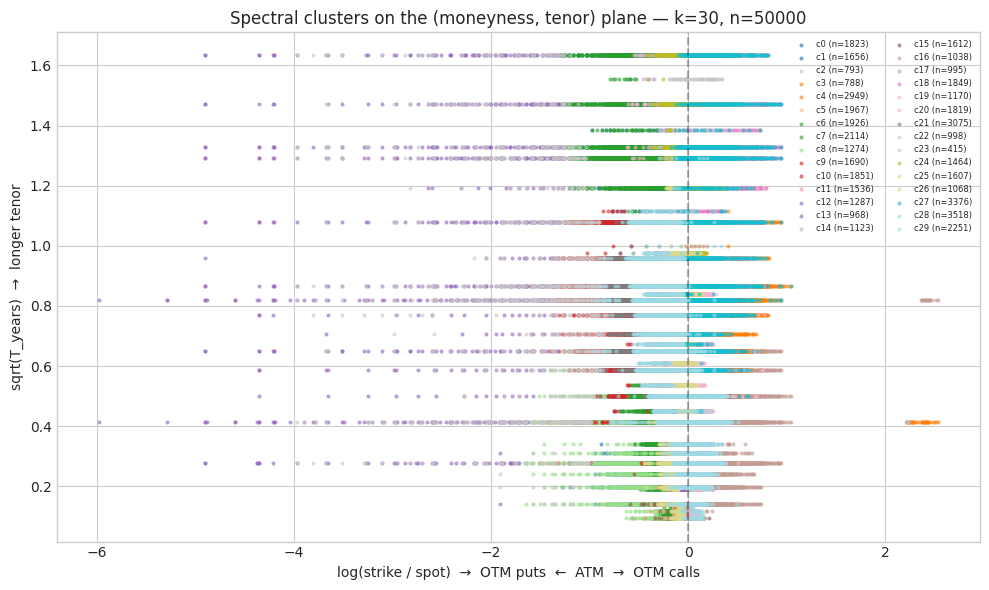

In [16]:
# Scatter on the (log-moneyness, sqrt-T) plane, colored by cluster.
import matplotlib.cm as cm

# Define cluster colors once; reused by the 3D surface below.
n_clusters = cpu_run["n_clusters"]
CLUSTER_COLORS = cm.get_cmap("tab20", n_clusters).colors

sub_df = df.iloc[idx_demo].copy()
sub_df["log_moneyness"] = np.log(sub_df["strike"] / sub_df["spot"])
sub_df["sqrt_T"] = np.sqrt(sub_df["T_years"])
sub_df["cluster"] = cpu_run["labels"]

fig, ax = plt.subplots(figsize=(10, 6))
for c in range(n_clusters):
    m = sub_df["cluster"] == c
    ax.scatter(sub_df.loc[m, "log_moneyness"], sub_df.loc[m, "sqrt_T"],
               s=4, alpha=0.5, color=CLUSTER_COLORS[c], label=f"c{c} (n={m.sum()})")
ax.axvline(0, color="k", linestyle="--", alpha=0.3)
ax.set_xlabel("log(strike / spot)  →  OTM puts  ←  ATM  →  OTM calls")
ax.set_ylabel("sqrt(T_years)  →  longer tenor")
ax.set_title(f"Spectral clusters on the (moneyness, tenor) plane — k={n_clusters}, n={cpu_run['n_samples']}")
ax.legend(loc="upper right", fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

Each row below shows representative averages per cluster: moneyness, tenor (`sqrt_T`), implied vol, the Greeks, and the call/put mix. They describe what kind of contract dominates each bucket. We don't label these archetypes here since cluster geometry is what matters for the CPU v GPU runtime benchmark below.

In [17]:
# Centroid table — mean of each interpretable variable per cluster.
sub_df["IV"] = df.iloc[idx_demo]["impliedVolatility"].values
sub_df["delta"] = delta[idx_demo]
sub_df["gamma"] = gamma[idx_demo]
sub_df["vega"]  = vega[idx_demo]
sub_df["is_call"] = (df.iloc[idx_demo]["option_type"] == "call").astype(int).values

centroids = sub_df.groupby("cluster").agg(
    n=("cluster", "size"),
    moneyness=("log_moneyness", "mean"),
    sqrt_T=("sqrt_T", "mean"),
    IV=("IV", "mean"),
    delta=("delta", "mean"),
    gamma=("gamma", "mean"),
    vega=("vega", "mean"),
    pct_call=("is_call", "mean"),
).round(3)
print(f"Cluster centroids — k={n_clusters}, mean of each interpretable feature per cluster:")
print(centroids.to_string())

Cluster centroids — k=30, mean of each interpretable feature per cluster:
            n  moneyness  sqrt_T     IV  delta  gamma     vega  pct_call
cluster                                                                 
0        1823     -0.485   1.343  0.471  0.872  0.001  108.382     1.000
1        1656     -0.466   0.307  0.868  0.972  0.001    7.478     1.000
2         793     -0.036   0.792  0.355 -0.370  0.002  212.777     0.000
3         788      0.021   0.234  0.994  0.577  0.005   49.565     0.918
4        2949      0.314   0.801  0.365  0.247  0.003   66.986     1.000
5        1967     -0.016   0.287  0.245 -0.367  0.017   31.738     0.000
6        1926     -0.560   1.386  0.354 -0.082  0.001   79.630     0.000
7        2114     -0.332   0.279  0.531 -0.014  0.001    4.218     0.000
8        1274     -0.724   0.272  1.065 -0.007  0.000    1.746     0.000
9        1690     -0.808   0.804  0.514 -0.017  0.000   13.579     0.000
10       1851     -0.113   0.217  0.299 -0.039  0.

**The vol surface, painted by cluster.** The 2D scatter above tells you which contracts went into which cluster. The 3D surface below tells you what the *vol surface itself* looks like for one ticker, painted by the cluster each region got assigned. Same data, same labels, different projection and the projection that survives a screenshot.

The surface is a cubic interpolation of observed implied vol over the (log-moneyness, days-to-expiration) grid for one ticker, smoothed lightly to remove interpolation spikes, masked to the convex hull of actual data so corners are not extrapolated. Cluster color at each grid point is taken from the nearest observed contract. The colors match the 2D scatter above.

Auto-selected: SPY (total=7569, puts=4372, calls=1511, gmean=2570.2)
SPY: 7201 contracts after trim, 24 clusters represented
  IV cap: 0.61, log-moneyness range: [-1.25, 0.42]
  grid: 50x50, 2434 cells inside mask, 66 masked out
  unmasked log-moneyness: [-1.25, 0.42]
  unmasked days-to-expiry: [3, 973]
  flicker: 565 cells differ from >=4 of 8 neighbors (23.2% of unmasked; bar is <5%)
  config used: sigma=2.5, knn_k=7, grid=50x50
wrote figures/vol_surface_clusters_SPY.png


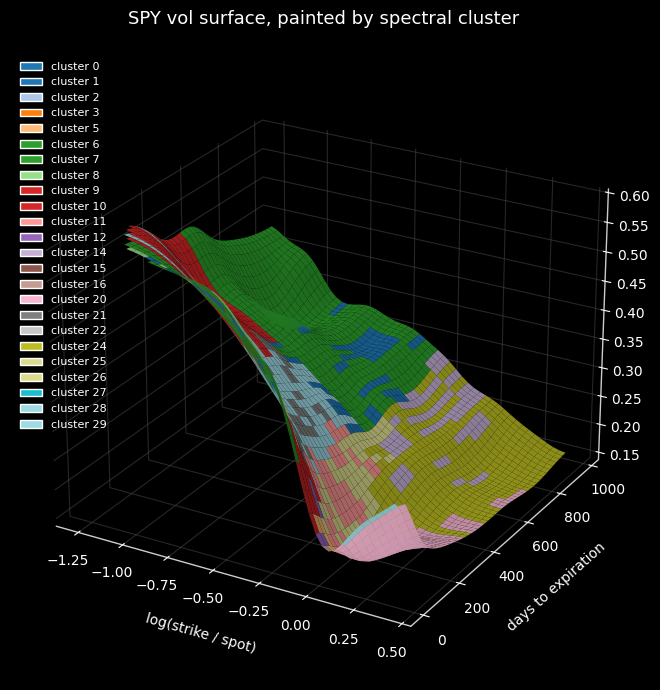

In [18]:
# 3D vol surface for one ticker, painted by spectral cluster from section 7.
from pathlib import Path
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.spatial import ConvexHull, cKDTree
from matplotlib.path import Path as MplPath
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection
from matplotlib.patches import Patch

# Override to force a specific ticker (None = auto-select).
TICKER_OVERRIDE = None

# Tunables for SPY-density data — see section 7.5 commentary.
SIGMA = 2.5     # Gaussian smoothing on IV grid (do not drop below 2.0 for SPY)
KNN_K = 7       # k for cluster majority vote (5 if 7 still flickers; not below 5)
GRID_N = 50     # grid resolution (dropped to 50 because 80 left flicker >5%)

# Auto-select: most balanced two-sided strike coverage.
sub_df["_lm"] = np.log(sub_df["strike"] / sub_df["spot"])
candidate_stats = []
for tk, g in sub_df.groupby("underlying"):
    total = len(g)
    puts = int((g["_lm"] < -0.05).sum())
    calls = int((g["_lm"] > 0.05).sum())
    if total >= 200 and puts >= 30 and calls >= 30:
        candidate_stats.append({
            "ticker": tk, "total": total, "puts": puts, "calls": calls,
            "gmean": float(np.sqrt(puts * calls)),
        })
sub_df.drop(columns=["_lm"], inplace=True)

if TICKER_OVERRIDE is not None:
    TICKER = TICKER_OVERRIDE
    matched = next((s for s in candidate_stats if s["ticker"] == TICKER), None)
    if matched is None:
        print(f"WARNING: override ticker {TICKER} did not pass density checks; rendering anyway.")
    else:
        print(f"Using override: {TICKER} (puts={matched['puts']}, calls={matched['calls']})")
else:
    if not candidate_stats:
        TICKER = sub_df["underlying"].value_counts().idxmax()
        print(f"WARNING: no ticker passed density bar; falling back to {TICKER}.")
    else:
        winner = max(candidate_stats, key=lambda s: s["gmean"])
        TICKER = winner["ticker"]
        print(f"Auto-selected: {TICKER} "
              f"(total={winner['total']}, puts={winner['puts']}, calls={winner['calls']}, "
              f"gmean={winner['gmean']:.1f})")

ticker_mask = sub_df["underlying"] == TICKER
t_df = sub_df.loc[ticker_mask].copy()
t_df["dte"] = t_df["T_years"] * 365.0
t_df["IV"] = df.loc[t_df.index, "impliedVolatility"].values

iv_cap = t_df["IV"].quantile(0.95)
t_df["IV_capped"] = t_df["IV"].clip(upper=iv_cap)

m_lo, m_hi = t_df["log_moneyness"].quantile([0.025, 0.975])
trim_mask = (t_df["log_moneyness"] >= m_lo) & (t_df["log_moneyness"] <= m_hi)
t_df = t_df.loc[trim_mask].copy()

x = t_df["log_moneyness"].to_numpy()
y = t_df["dte"].to_numpy()
z = t_df["IV_capped"].to_numpy()
cl = t_df["cluster"].to_numpy()
print(f"{TICKER}: {len(t_df)} contracts after trim, {len(np.unique(cl))} clusters represented")
print(f"  IV cap: {iv_cap:.2f}, log-moneyness range: [{m_lo:.2f}, {m_hi:.2f}]")

# Grid in (log-moneyness, days-to-expiration).
xi = np.linspace(x.min(), x.max(), GRID_N)
yi = np.linspace(y.min(), y.max(), GRID_N)
XI, YI = np.meshgrid(xi, yi)

# Linear interpolation; smoothed only over valid (non-NaN) cells so the
# convex-hull mask doesn't bleed NaN edge effects inward.
ZI = griddata((x, y), z, (XI, YI), method="linear")
valid = ~np.isnan(ZI)
ZI_filled = np.where(valid, ZI, 0.0)
weight = valid.astype(float)
ZI_blur = gaussian_filter(ZI_filled, sigma=SIGMA)
W_blur = gaussian_filter(weight, sigma=SIGMA)
with np.errstate(invalid="ignore", divide="ignore"):
    ZI_smooth = np.where(W_blur > 0, ZI_blur / W_blur, np.nan)

# Convex hull, scaled outward 5% globally + 8% extra on call side.
points = np.column_stack([x, y])
hull = ConvexHull(points)
hull_pts = points[hull.vertices]
centroid = hull_pts.mean(axis=0)
scaled_pts = centroid + 1.05 * (hull_pts - centroid)
call_side = scaled_pts[:, 0] > 0
scaled_pts[call_side, 0] = centroid[0] + 1.13 * (scaled_pts[call_side, 0] - centroid[0])
hull_path = MplPath(scaled_pts)

grid_points = np.column_stack([XI.ravel(), YI.ravel()])
inside = hull_path.contains_points(grid_points).reshape(XI.shape)
ZI_smooth[~inside] = np.nan

unmasked = int(inside.sum())
masked = int(inside.size - unmasked)
print(f"  grid: {GRID_N}x{GRID_N}, {unmasked} cells inside mask, {masked} masked out")
print(f"  unmasked log-moneyness: [{XI[inside].min():.2f}, {XI[inside].max():.2f}]")
print(f"  unmasked days-to-expiry: [{YI[inside].min():.0f}, {YI[inside].max():.0f}]")

# Cluster assignment — k-NN majority vote instead of nearest-neighbor.
tree = cKDTree(points)
_, nn_idx = tree.query(grid_points, k=KNN_K)
neighbor_labels = cl[nn_idx]  # (n_grid, k)

# Per-row majority vote via bincount (cleaner than scipy.stats.mode for our use).
def majority(row):
    return np.bincount(row).argmax()

cluster_grid = np.apply_along_axis(majority, 1, neighbor_labels).reshape(XI.shape)

# Cell-flicker estimate: count unmasked cells whose assigned cluster differs
# from >= 4 of their 8 immediate neighbors. <5% of unmasked is the bar.
def flicker_count(grid, mask):
    n_diff = np.zeros_like(grid, dtype=int)
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx == 0 and dy == 0:
                continue
            shifted = np.roll(np.roll(grid, dy, axis=0), dx, axis=1)
            valid_neighbor = np.roll(np.roll(mask, dy, axis=0), dx, axis=1)
            n_diff += ((shifted != grid) & valid_neighbor).astype(int)
    return int(((n_diff >= 4) & mask).sum())

flicker = flicker_count(cluster_grid, inside)
flicker_pct = 100.0 * flicker / max(unmasked, 1)
print(f"  flicker: {flicker} cells differ from >=4 of 8 neighbors "
      f"({flicker_pct:.1f}% of unmasked; bar is <5%)")
print(f"  config used: sigma={SIGMA}, knn_k={KNN_K}, grid={GRID_N}x{GRID_N}")

# Build face colors.
face_colors = np.zeros((GRID_N - 1, GRID_N - 1, 4))
cg_quad = cluster_grid[:-1, :-1]
inside_quad = inside[:-1, :-1] & inside[1:, :-1] & inside[:-1, 1:] & inside[1:, 1:]
for c in range(n_clusters):
    face_colors[cg_quad == c] = CLUSTER_COLORS[c]
face_colors[~inside_quad] = (0, 0, 0, 0)

fig = plt.figure(figsize=(11, 7))
fig.patch.set_facecolor("black")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

ax.plot_surface(
    XI, YI, ZI_smooth,
    facecolors=face_colors,
    rstride=1, cstride=1,
    linewidth=0, antialiased=True,
    shade=True,
)

ax.view_init(elev=25, azim=-60)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.label.set_color("white")
    axis.set_pane_color((0.0, 0.0, 0.0, 0.0))
    axis._axinfo["grid"]["color"] = (0.3, 0.3, 0.3, 0.5)
ax.tick_params(colors="white")
ax.set_xlabel("log(strike / spot)", color="white", labelpad=10)
ax.set_ylabel("days to expiration", color="white", labelpad=10)
ax.set_zlabel("implied volatility", color="white", labelpad=10)
ax.set_title(f"{TICKER} vol surface, painted by spectral cluster", color="white", pad=20, fontsize=13)

clusters_present = sorted(np.unique(cl).tolist())
handles = [Patch(facecolor=CLUSTER_COLORS[c], edgecolor="white", label=f"cluster {c}")
           for c in clusters_present]
leg = ax.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.85,
                facecolor="black", edgecolor="white")
for text in leg.get_texts():
    text.set_color("white")

plt.tight_layout()

out_dir = Path("figures")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / f"vol_surface_clusters_{TICKER}.png"
fig.savefig(out_path, dpi=220, facecolor="black", bbox_inches="tight")
print(f"wrote {out_path}")

plt.show()

This is a recognizable equity vol surface. The downward skew on the put wing and term structure rising into longer tenors are partitioned into smooth color regions corresponding to the spectral clusters. If the surface looks spiky or the corners are wild, the convex-hull mask isn't tight enough and the alpha shape needs tightening or to drop to a smaller grid.

---

# 5. Full Benchmark Grid

5 sample sizes × 3 workload archetypes = **15 scenarios**, 3 trials each.

| Workload | k |
|---|---|
| `skew_buckets` | 6 |
| `risk_buckets` | 15 |
| `regime_states` | 30 |

Sample sizes: 
* 5K
* 15K
* 25K
* 36K
* 50K
  

Same parameters as `cluster_options()`.

### 5.1 Restart the Kernel Before Running the Grid

> **To run the full benchmark grid, restart the kernel first.**
>
> The grid runs both CPU and GPU loops in one section. Previous sections loaded `cuml.accel`, which permanently patches `SpectralClustering` in this kernel. To get a clean CPU baseline, restart the kernel now.
>
> **From the Jupyter menu:** Kernel → Restart.
>
> **Then re-run these cells in order before continuing:**
> Run the code in sections 2.1 and 2.2 that prepares the data and define `cluster_options()`
>
> Then run the cells in this section top to bottom. WARNING: This can take over an hour for the CPU portion of the benchmarking.

### 5.2 CPU Grid Loop

In [6]:
# 64 Minutes to run this on AMD Ryzen Threadripper PRO 7965WX 24-Cores with 256GB RAM


SAMPLE_SIZES = [5000, 15000, 25000, 36000, 50000]
WORKLOADS = [
    ("skew_buckets",   6),
    ("risk_buckets",  15),
    ("regime_states", 30),
]
N_TRIALS = 3

cpu_results = []
for n in SAMPLE_SIZES:
    idx = np.random.default_rng(0).choice(X.shape[0], size=n, replace=False)
    X_sub = np.ascontiguousarray(X[idx])
    for workload, k in WORKLOADS:
        trial_times = []
        for trial in range(N_TRIALS):
            run = cluster_options(X_sub, n_clusters=k, random_state=42 + trial)
            trial_times.append(run["fit_seconds"])
        cpu_results.append({
            "workload": workload, "n_samples": n, "n_clusters": k,
            "median_seconds": float(np.median(trial_times)),
            "min_seconds": float(np.min(trial_times)),
            "max_seconds": float(np.max(trial_times)),
        })
        print(f"CPU  {workload:14s} n={n:6d} k={k:3d}: median {np.median(trial_times):7.2f}s")

CPU  skew_buckets   n=  5000 k=  6: median    1.14s
CPU  risk_buckets   n=  5000 k= 15: median    1.21s
CPU  regime_states  n=  5000 k= 30: median    1.34s
CPU  skew_buckets   n= 15000 k=  6: median   13.66s
CPU  risk_buckets   n= 15000 k= 15: median   14.25s
CPU  regime_states  n= 15000 k= 30: median   15.57s
CPU  skew_buckets   n= 25000 k=  6: median   47.10s
CPU  risk_buckets   n= 25000 k= 15: median   50.41s
CPU  regime_states  n= 25000 k= 30: median   52.48s
CPU  skew_buckets   n= 36000 k=  6: median  111.32s
CPU  risk_buckets   n= 36000 k= 15: median  114.98s
CPU  regime_states  n= 36000 k= 30: median  117.49s
CPU  skew_buckets   n= 50000 k=  6: median  240.53s
CPU  risk_buckets   n= 50000 k= 15: median  244.81s
CPU  regime_states  n= 50000 k= 30: median  250.96s


### 5.3 Load `cuml.accel`

Same loop body as above; only the backend changes.

In [7]:
%load_ext cuml.accel

### 5.4 Run the Grid Loop

In [ ]:
# 25 seconds to run this on NVIDIA RTX PRO 6000 Blackwell Workstation Edition

gpu_results = []
for n in SAMPLE_SIZES:
    idx = np.random.default_rng(0).choice(X.shape[0], size=n, replace=False)
    X_sub = np.ascontiguousarray(X[idx])
    for workload, k in WORKLOADS:
        trial_times = []
        for trial in range(N_TRIALS):
            run = cluster_options(X_sub, n_clusters=k, random_state=42 + trial)
            trial_times.append(run["fit_seconds"])
        gpu_results.append({
            "workload": workload, "n_samples": n, "n_clusters": k,
            "median_seconds": float(np.median(trial_times)),
            "min_seconds": float(np.min(trial_times)),
            "max_seconds": float(np.max(trial_times)),
        })
        print(f"GPU  {workload:14s} n={n:6d} k={k:3d}: median {np.median(trial_times):7.2f}s")


GPU  skew_buckets   n=  5000 k=  6: median    0.07s
GPU  risk_buckets   n=  5000 k= 15: median    0.11s
GPU  regime_states  n=  5000 k= 30: median    0.22s
GPU  skew_buckets   n= 15000 k=  6: median    0.16s
GPU  risk_buckets   n= 15000 k= 15: median    0.19s
GPU  regime_states  n= 15000 k= 30: median    0.30s
GPU  skew_buckets   n= 25000 k=  6: median    0.32s
GPU  risk_buckets   n= 25000 k= 15: median    0.38s
GPU  regime_states  n= 25000 k= 30: median    0.63s
GPU  skew_buckets   n= 36000 k=  6: median    0.61s
GPU  risk_buckets   n= 36000 k= 15: median    0.68s
GPU  regime_states  n= 36000 k= 30: median    0.94s
GPU  skew_buckets   n= 50000 k=  6: median    0.98s
GPU  risk_buckets   n= 50000 k= 15: median    1.07s
GPU  regime_states  n= 50000 k= 30: median    1.36s


### 5.5 Wall-Clock and Speedup

Error bars are min/max across 3 trials per scenario. Source dataframes built from `cpu_results` / `gpu_results` in memory.

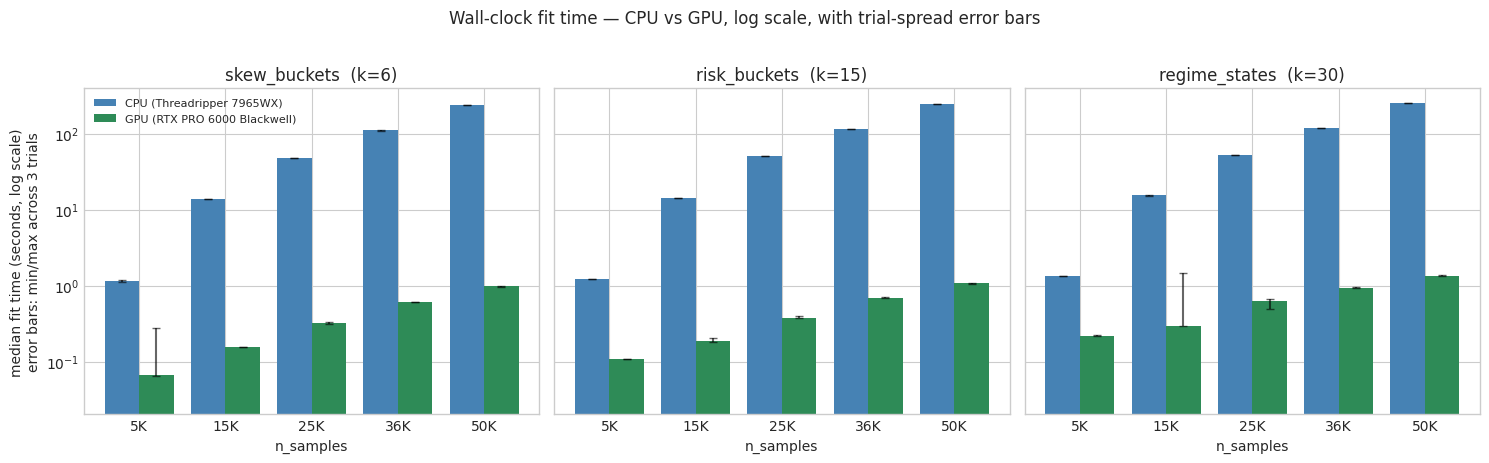

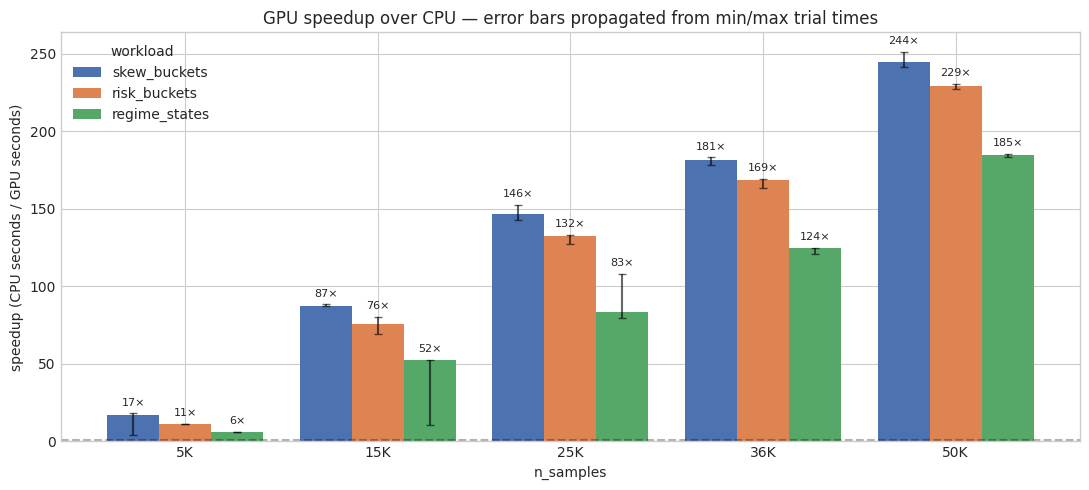

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

cpu = pd.DataFrame(cpu_results)
gpu = pd.DataFrame(gpu_results)

join_keys = ["workload", "n_samples", "n_clusters"]
time_cols = ["median_seconds", "min_seconds", "max_seconds"]

bench = cpu[join_keys + time_cols].rename(
    columns={"median_seconds": "cpu_s", "min_seconds": "cpu_min", "max_seconds": "cpu_max"}
).merge(
    gpu[join_keys + time_cols].rename(
        columns={"median_seconds": "gpu_s", "min_seconds": "gpu_min", "max_seconds": "gpu_max"}
    ),
    on=join_keys,
)
bench["speedup"] = bench["cpu_s"] / bench["gpu_s"]
bench = bench.sort_values(["n_samples", "n_clusters"]).reset_index(drop=True)

workloads = ["skew_buckets", "risk_buckets", "regime_states"]

# ----- Wall-clock chart -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, wl in zip(axes, workloads):
    sub = bench[bench["workload"] == wl].sort_values("n_samples")
    x = np.arange(len(sub))
    width = 0.4
    cpu_err = np.array([sub["cpu_s"] - sub["cpu_min"], sub["cpu_max"] - sub["cpu_s"]])
    gpu_err = np.array([sub["gpu_s"] - sub["gpu_min"], sub["gpu_max"] - sub["gpu_s"]])
    ax.bar(x - width/2, sub["cpu_s"], width, yerr=cpu_err, capsize=3,
           label="CPU (Threadripper 7965WX)", color="steelblue", error_kw={"alpha": 0.6})
    ax.bar(x + width/2, sub["gpu_s"], width, yerr=gpu_err, capsize=3,
           label="GPU (RTX PRO 6000 Blackwell)", color="seagreen", error_kw={"alpha": 0.6})
    ax.set_xticks(x); ax.set_xticklabels([f"{n//1000}K" for n in sub["n_samples"]])
    ax.set_title(f"{wl}  (k={sub['n_clusters'].iloc[0]})")
    ax.set_xlabel("n_samples")
    ax.set_yscale("log")
axes[0].set_ylabel("median fit time (seconds, log scale)\nerror bars: min/max across 3 trials")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Wall-clock fit time — CPU vs GPU, log scale, with trial-spread error bars", y=1.02)
plt.tight_layout(); plt.show()

# ----- Speedup chart -----
fig, ax = plt.subplots(figsize=(11, 5))
n_samples_unique = sorted(bench["n_samples"].unique())
x = np.arange(len(n_samples_unique))
width = 0.27
colors = {"skew_buckets": "#4c72b0", "risk_buckets": "#dd8452", "regime_states": "#55a868"}
for i, wl in enumerate(workloads):
    sub = bench[bench["workload"] == wl].set_index("n_samples").reindex(n_samples_unique)
    sp_low = sub["cpu_min"] / sub["gpu_max"]
    sp_high = sub["cpu_max"] / sub["gpu_min"]
    err = np.array([sub["speedup"] - sp_low, sp_high - sub["speedup"]])
    ax.bar(x + (i - 1) * width, sub["speedup"].values, width,
           yerr=err.values if hasattr(err, 'values') else err,
           capsize=3, label=wl, color=colors[wl], error_kw={"alpha": 0.6})
    for j, v in enumerate(sub["speedup"].values):
        if not np.isnan(v):
            ax.text(x[j] + (i - 1) * width, sp_high.values[j] + 5, f"{v:.0f}×", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"{n//1000}K" for n in n_samples_unique])
ax.set_xlabel("n_samples")
ax.set_ylabel("speedup (CPU seconds / GPU seconds)")
ax.set_title("GPU speedup over CPU — error bars propagated from min/max trial times")
ax.legend(title="workload")
ax.axhline(1, color="k", linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()


**Headline numbers (read from the chart above):**

The speedup grows with both `n_samples` and `n_clusters` because the eigensolver becomes the bottleneck. Lanczos on GPU stays fast while sklearn's arpack is slow at these scales. The largest scenario (highest n×k) and the maximum-speedup scenario are typically different points in the grid.

---

# 6. Next Steps

**One concrete next step:**
Before running your next sklearn estimator, add one line. Add `%load_ext cuml.accel` before your sklearn imports.

→ **[NVIDIA CUDA-X Data Science Libraries — full estimator coverage list](https://developer.nvidia.com/topics/ai/data-science/cuda-x-data-science-libraries)**

---

---

# Appendix

## Options Evaluation
* Get Data
* Run Spectral Clustering
* Tabular View
* 2D View
* 3D Surface

### Options Data
Provide your own data or grab from yfinance

**EDIT** the TICKERS list for your own portfolio  
**NOTE** this is not trading advice, education purposes only

In [10]:
TICKERS = ["QQQ", "SPY", "IWM", "DIA", "AAPL", "MSFT", "NVDA", "TSLA", "AMZN", "GOOGL"]

In [11]:
%load_ext cuml.accel

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [12]:
# Grab from yfinance
import time
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm

In [13]:
SLEEP_SECONDS = 1.6  # pause between requests so yfinance doesn't rate-limit

frames = []
for ticker in tqdm(TICKERS):
    print(f"fetching {ticker}...", end=" ", flush=True)
    tk = yf.Ticker(ticker)

    # spot price — needed for moneyness and Greeks
    try:
        spot = float(tk.fast_info["last_price"])
    except Exception:
        try:
            spot = float(tk.history(period="1d")["Close"].iloc[-1])
        except Exception as e:
            print(f"skipped (no spot): {e}")
            continue

    expirations = tk.options
    if not expirations:
        print("skipped (no expirations)")
        continue

    ticker_frames = []
    for exp in expirations:
        try:
            chain = tk.option_chain(exp)
        except Exception as e:
            print(f"\n  skipped {ticker} {exp}: {e}")
            continue
        calls = chain.calls.assign(option_type="call")
        puts  = chain.puts.assign(option_type="put")
        ticker_frames.append(pd.concat([calls, puts], ignore_index=True))
        time.sleep(SLEEP_SECONDS)

    if not ticker_frames:
        print("no chains returned")
        continue

    t_df = pd.concat(ticker_frames, ignore_index=True)
    t_df["spot"]       = spot
    t_df["underlying"] = ticker
    frames.append(t_df)
    print(f"{len(t_df):,} contracts across {len(expirations)} expirations (spot={spot:.2f})")

df = pd.concat(frames, ignore_index=True)

# OCC symbol format: ROOT + YYMMDD + C/P + STRIKE(8 digits, x1000)
# example: QQQ260116C00500000  → expires 2026-01-16
exp_str = df["contractSymbol"].str.extract(r"[A-Z]+(\d{6})[CP]\d{8}")[0]
df["expiration"] = pd.to_datetime(exp_str, format="%y%m%d")
df["fetched_at"] = pd.Timestamp.now().normalize()
df["T_years"]    = (df["expiration"] - df["fetched_at"]).dt.total_seconds() / (365.0 * 24 * 3600)

# same filters as Section 2.1 so the downstream pipeline is identical
df = df[
    (df["impliedVolatility"] > 0.01)
    & (df["T_years"] > 1 / 365)
    & (df["spot"] > 0)
    & (df["strike"] > 0)
].reset_index(drop=True)

print()
print(f"total contracts:  {len(df):,}")
print(f"underliers:       {df['underlying'].nunique()}")
print(f"tenor range:      {df['T_years'].min():.3f} to {df['T_years'].max():.2f} years")
print(f"IV range:         {df['impliedVolatility'].min():.3f} to {df['impliedVolatility'].max():.2f}")

  0%|          | 0/10 [00:00<?, ?it/s]

fetching QQQ... 

 10%|█         | 1/10 [00:49<07:27, 49.76s/it]

8,827 contracts across 29 expirations (spot=711.79)
fetching SPY... 

 20%|██        | 2/10 [01:44<07:02, 52.83s/it]

...

5,006 contracts across 22 expirations (spot=412.81)
fetching AMZN... 

 90%|█████████ | 9/10 [06:23<00:39, 39.46s/it]

2,208 contracts across 23 expirations (spot=264.24)
fetching GOOGL... 

100%|██████████| 10/10 [07:02<00:00, 42.27s/it]

3,840 contracts across 23 expirations (spot=388.00)

total contracts:  42,031
underliers:       10
tenor range:      0.005 to 2.58 years
IV range:         0.016 to 20.77


In [15]:
df.to_parquet("user_data_unprepped.parquet", index=False)

In [16]:
df = pd.read_parquet("user_data_unprepped.parquet")

### Data Prep

In [17]:
# Black-Scholes Greeks, vectorized over the full DataFrame.
# r = 0.04, q = 0.0 — reasonable defaults for short-dated US single-name options.
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

S = df["spot"].to_numpy()
K = df["strike"].to_numpy()
T = df["T_years"].to_numpy()
sigma = df["impliedVolatility"].to_numpy()
is_call = (df["option_type"] == "call").to_numpy()

r, q = 0.04, 0.0

sqrtT = np.sqrt(T)
d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
d2 = d1 - sigma * sqrtT

pdf_d1 = norm.pdf(d1)
disc_q = np.exp(-q * T)
disc_r = np.exp(-r * T)

# Delta: directional exposure; flips sign for puts.
delta = np.where(is_call,
                 disc_q * norm.cdf(d1),
                 -disc_q * norm.cdf(-d1))

# Gamma and vega: same formula for calls and puts.
gamma = disc_q * pdf_d1 / (S * sigma * sqrtT)
vega  = S * disc_q * pdf_d1 * sqrtT

# Theta: time decay. Common term plus call/put-specific tail.
theta_common = -S * disc_q * pdf_d1 * sigma / (2.0 * sqrtT)
theta = np.where(is_call,
                 theta_common - r * K * disc_r * norm.cdf(d2)  + q * S * disc_q * norm.cdf(d1),
                 theta_common + r * K * disc_r * norm.cdf(-d2) - q * S * disc_q * norm.cdf(-d1))

features = np.column_stack([
    np.log(K / S),         # log-moneyness
    sqrtT,                 # vol-time
    np.log(sigma),         # log-IV
    is_call.astype(float), # call/put indicator
    delta, gamma, vega, theta,
])

X = StandardScaler().fit_transform(features).astype(np.float32)
X = np.ascontiguousarray(X)

print(f"feature matrix: {X.shape}, dtype={X.dtype}")
print(f"per-feature mean (should be ~0): {X.mean(axis=0).round(3)}")
print(f"per-feature std  (should be ~1): {X.std(axis=0).round(3)}")


feature matrix: (42031, 8), dtype=float32
per-feature mean (should be ~0): [-0.  0. -0.  0.  0. -0. -0. -0.]
per-feature std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


### Run Spectral Clustering

In [18]:
# Run cluster_options() on the yfinance feature matrix.
# Section 2 already defined cluster_options() and (if you ran Section 3) loaded cuml.accel,
# so this call runs on GPU automatically. If you skipped Section 3, it runs on CPU.

n_samples = X.shape[0]

# Scale k to dataset size — single-ticker mixes are ~10x smaller than the 54K benchmark.
# Rule of thumb: ~500 contracts per cluster so each bucket has enough mass to be meaningful.
N_CLUSTERS = max(6, min(30, n_samples // 500))

print(f"clustering {n_samples:,} contracts into k={N_CLUSTERS} clusters...")

run = cluster_options(X, n_clusters=N_CLUSTERS)

print(f"fit time:    {run['fit_seconds']:.2f}s")
print(f"n_samples:   {run['n_samples']:,}")
print(f"n_clusters:  {run['n_clusters']}")
print(f"label range: {run['labels'].min()}..{run['labels'].max()}")
print(f"cluster sizes (sorted): {sorted(np.bincount(run['labels']).tolist())}")

clustering 42,031 contracts into k=30 clusters...
fit time:    1.09s
n_samples:   42,031
n_clusters:  30
label range: 0..29
cluster sizes (sorted): [460, 619, 684, 761, 776, 788, 799, 831, 905, 946, 975, 1193, 1194, 1230, 1269, 1305, 1477, 1524, 1569, 1589, 1590, 1594, 1718, 1724, 2070, 2164, 2195, 2472, 2714, 2896]


### 2D Surface

**How to read this plot.**

Each dot is one options contract. The x-axis is log-moneyness (`log(strike/spot)`). Negative values are OTM puts, zero is ATM, positive values are OTM calls. The y-axis is `sqrt(T)`. Higher y-axis values means longer until expiration. Color is the cluster the spectral algorithm assigned.

A few things to look for:

- **Clusters form bands, not blobs.** Spectral clustering on this feature space groups contracts by *risk archetype*: short-dated ATM gamma plays, long-dated OTM put-wing hedges, deep-ITM calls behaving like the underlying, etc. The bands tend to run diagonally because moneyness and tenor co-vary in how they shape Greeks.
  
- **Vertical stripes at each ticker.** When you cluster across multiple underliers, you'll see vertical bands at each ticker's listed strikes (relative to its own spot). The scaler removes absolute price levels via `log(K/S)`, so the *clusters* don't separate by ticker — but the *dots* still land on each ticker's strike grid.
  
- **Cluster count in the legend.** `(n=...)` is how many contracts landed in each bucket. Clusters that are very small relative to their neighbors usually mean a tail region (deep OTM, very long-dated) that the algorithm correctly isolated rather than merged into a neighbor.
  
- **What this view hides.** Two contracts at the same `(moneyness, tenor)` point with very different IV or Greeks will overlap visually but live in different clusters. Hover on the interactive chart below to see IV, Greeks, expiration, and ticker for any individual contract — and the centroid table and 3D surface further down show cluster-level summaries of those dimensions.
  


In [ ]:
# Interactive 2D scatter — hover shows contract details.
# Renders inline locally; GitHub strips JS so the static matplotlib chart above is the canonical view.
import plotly.express as px

n_clusters = run["n_clusters"]
# CLUSTER_COLORS = cm.get_cmap("tab20", n_clusters).colors

plot_df = df.copy()
plot_df["log_moneyness"] = np.log(plot_df["strike"] / plot_df["spot"])
plot_df["sqrt_T"] = np.sqrt(plot_df["T_years"])
plot_df["cluster"] = run["labels"]

hover_df = plot_df.copy()
hover_df["cluster"] = hover_df["cluster"].astype(str)  # categorical color, not continuous
hover_df["IV"] = df["impliedVolatility"].values
hover_df["expiration_str"] = hover_df["expiration"].dt.strftime("%Y-%m-%d")
hover_df["dte"] = (hover_df["T_years"] * 365).round(0).astype(int)

# tab20 hex codes to match the matplotlib palette above
TAB20_HEX = [
    "#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#2ca02c", "#98df8a",
    "#d62728", "#ff9896", "#9467bd", "#c5b0d5", "#8c564b", "#c49c94",
    "#e377c2", "#f7b6d2", "#7f7f7f", "#c7c7c7", "#bcbd22", "#dbdb8d",
    "#17becf", "#9edae5",
]
color_map = {str(c): TAB20_HEX[c % 20] for c in range(n_clusters)}

fig = px.scatter(
    hover_df,
    x="log_moneyness",
    y="sqrt_T",
    color="cluster",
    color_discrete_map=color_map,
    category_orders={"cluster": [str(c) for c in range(n_clusters)]},
    hover_data={
        "underlying": True,
        "option_type": True,
        "strike": ":.2f",
        "spot": ":.2f",
        "expiration_str": True,
        "dte": True,
        "IV": ":.3f",
        "cluster": True,
        "log_moneyness": ":.3f",
        "sqrt_T": ":.3f",
    },
    labels={
        "log_moneyness": "log(strike / spot)",
        "sqrt_T": "sqrt(T_years)",
        "expiration_str": "expiration",
        "dte": "days to expiry",
    },
    title=f"Spectral clusters — k={n_clusters}, n={run['n_samples']:,} "
          f"(hover for contract details)",
)
fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.4)
fig.update_layout(
    width=1100, height=650,
    legend=dict(title="cluster", itemsizing="constant"),
)
fig.show()


### 3D Surface

In [ ]:
# Interactive 3D vol surface, painted by spectral cluster.
# One subplot per ticker; pick a ticker from the dropdown above the plot.
import plotly.graph_objects as go
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, zoom
from scipy.spatial import ConvexHull, cKDTree
from matplotlib.path import Path as MplPath

SIGMA = 2.5
KNN_K = 7
GRID_N = 50
COLOR_UPSAMPLE = 4  # upsample cluster grid to shrink Plotly's gradient halos to ~1 px

# pull IV onto plot_df so we don't keep reindexing df
plot_df["IV"] = df["impliedVolatility"].values
plot_df["dte"] = plot_df["T_years"] * 365.0

# tab20 hex codes — match the 2D scatter palette
TAB20_HEX = [
    "#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#2ca02c", "#98df8a",
    "#d62728", "#ff9896", "#9467bd", "#c5b0d5", "#8c564b", "#c49c94",
    "#e377c2", "#f7b6d2", "#7f7f7f", "#c7c7c7", "#bcbd22", "#dbdb8d",
    "#17becf", "#9edae5",
]

def build_surface_for_ticker(ticker):
    """Return a Plotly Surface trace for one ticker, or None if too sparse."""
    t_df = plot_df[plot_df["underlying"] == ticker].copy()
    if len(t_df) < 200:
        return None

    # cap IV outliers and trim moneyness tails — same as Section 4.1
    iv_cap = t_df["IV"].quantile(0.95)
    t_df["IV_capped"] = t_df["IV"].clip(upper=iv_cap)
    m_lo, m_hi = t_df["log_moneyness"].quantile([0.025, 0.975])
    t_df = t_df[(t_df["log_moneyness"] >= m_lo) & (t_df["log_moneyness"] <= m_hi)]
    if len(t_df) < 200:
        return None

    x = t_df["log_moneyness"].to_numpy()
    y = t_df["dte"].to_numpy()
    z = t_df["IV_capped"].to_numpy()
    cl = t_df["cluster"].to_numpy()

    xi = np.linspace(x.min(), x.max(), GRID_N)
    yi = np.linspace(y.min(), y.max(), GRID_N)
    XI, YI = np.meshgrid(xi, yi)

    ZI = griddata((x, y), z, (XI, YI), method="linear")
    valid = ~np.isnan(ZI)
    ZI_filled = np.where(valid, ZI, 0.0)
    weight = valid.astype(float)
    ZI_blur = gaussian_filter(ZI_filled, sigma=SIGMA)
    W_blur = gaussian_filter(weight, sigma=SIGMA)
    with np.errstate(invalid="ignore", divide="ignore"):
        ZI_smooth = np.where(W_blur > 0, ZI_blur / W_blur, np.nan)

    # convex hull mask, slight outward scale
    points = np.column_stack([x, y])
    hull = ConvexHull(points)
    hull_pts = points[hull.vertices]
    centroid = hull_pts.mean(axis=0)
    scaled_pts = centroid + 1.05 * (hull_pts - centroid)
    hull_path = MplPath(scaled_pts)
    grid_points = np.column_stack([XI.ravel(), YI.ravel()])
    inside = hull_path.contains_points(grid_points).reshape(XI.shape)
    ZI_smooth[~inside] = np.nan

    # kNN majority-vote cluster assignment per grid cell
    tree = cKDTree(points)
    _, nn_idx = tree.query(grid_points, k=KNN_K)
    neighbor_labels = cl[nn_idx]
    cluster_grid = np.array(
        [np.bincount(row).argmax() for row in neighbor_labels]
    ).reshape(XI.shape)

    # Upsample the geometry AND the cluster grid by COLOR_UPSAMPLE×.
    # Plotly's Surface still interpolates surfacecolor between vertices, but with
    # 4× resolution the gradient bands shrink to ~1 pixel and visually disappear.
    # `zoom` with order=0 = nearest-neighbor (no blending of cluster IDs across edges).
    XI_hi = zoom(XI, COLOR_UPSAMPLE, order=1)
    YI_hi = zoom(YI, COLOR_UPSAMPLE, order=1)
    ZI_filled_for_zoom = np.where(np.isnan(ZI_smooth), 0.0, ZI_smooth)
    ZI_hi = zoom(ZI_filled_for_zoom, COLOR_UPSAMPLE, order=1)
    inside_hi = zoom(inside.astype(np.uint8), COLOR_UPSAMPLE, order=0).astype(bool)
    cluster_grid_hi = zoom(cluster_grid, COLOR_UPSAMPLE, order=0)
    ZI_hi = np.where(inside_hi, ZI_hi, np.nan)
    cluster_grid_masked = np.where(inside_hi, cluster_grid_hi, -1)

    # Discrete colorscale: each cluster gets a flat band of width 1/n_clusters.
    n_clusters_local = int(plot_df["cluster"].max()) + 1
    boundaries = np.linspace(0, 1, n_clusters_local + 1)
    colorscale = []
    for c in range(n_clusters_local):
        color = TAB20_HEX[c % 20]
        colorscale.append([boundaries[c], color])
        colorscale.append([boundaries[c + 1], color])

    # Hover text on the upsampled grid would be 16× as much memory; build at low res
    # and upsample with nearest-neighbor so each high-res cell points back to a real one.
    hover_lo = np.empty(XI.shape, dtype=object)
    for i in range(XI.shape[0]):
        for j in range(XI.shape[1]):
            if inside[i, j]:
                hover_lo[i, j] = (
                    f"cluster: {int(cluster_grid[i, j])}<br>"
                    f"log-moneyness: {XI[i, j]:.2f}<br>"
                    f"DTE: {YI[i, j]:.0f}<br>"
                    f"IV: {ZI_smooth[i, j]:.3f}"
                )
            else:
                hover_lo[i, j] = ""
    # repeat each low-res cell COLOR_UPSAMPLE× along both axes
    hover_text = np.repeat(np.repeat(hover_lo, COLOR_UPSAMPLE, axis=0),
                           COLOR_UPSAMPLE, axis=1)
    # trim or pad to match XI_hi shape exactly (zoom can be off by 1)
    hover_text = hover_text[:XI_hi.shape[0], :XI_hi.shape[1]]

    return go.Surface(
        x=XI_hi, y=YI_hi, z=ZI_hi,
        surfacecolor=cluster_grid_masked.astype(float),
        cmin=0, cmax=n_clusters_local - 1,
        colorscale=colorscale,
        showscale=False,
        name=ticker,
        text=hover_text,
        hovertemplate="%{text}<extra>" + ticker + "</extra>",
        visible=False,
    )

# build one trace per ticker; only first is visible by default
tickers = sorted(plot_df["underlying"].unique())
traces = []
labels = []
for tk in tickers:
    tr = build_surface_for_ticker(tk)
    if tr is not None:
        traces.append(tr)
        labels.append(tk)

if not traces:
    raise RuntimeError("No ticker had enough contracts to build a surface.")

traces[0].visible = True

# dropdown to switch tickers
buttons = []
for i, tk in enumerate(labels):
    vis = [j == i for j in range(len(traces))]
    buttons.append(dict(label=tk, method="update",
                        args=[{"visible": vis},
                              {"title": f"{tk} vol surface, painted by spectral cluster"}]))

fig = go.Figure(data=traces)
fig.update_layout(
    title=f"{labels[0]} vol surface, painted by spectral cluster",
    scene=dict(
        xaxis_title="log(strike / spot)",
        yaxis_title="days to expiration",
        zaxis_title="implied volatility",
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9)),
    ),
    width=1000, height=700,
    updatemenus=[dict(
        buttons=buttons, direction="down", showactive=True,
        x=0.02, y=0.98, xanchor="left", yanchor="top",
    )],
    margin=dict(l=0, r=0, t=60, b=0),
)
fig.show()


### Tabular View

In [21]:
# Per-cluster centroids: mean of each interpretable feature per cluster.
# Tells you what kind of contract dominates each bucket.

centroid_df = df.copy()
centroid_df["log_moneyness"] = np.log(centroid_df["strike"] / centroid_df["spot"])
centroid_df["sqrt_T"] = np.sqrt(centroid_df["T_years"])
centroid_df["IV"] = centroid_df["impliedVolatility"]
centroid_df["delta"] = delta
centroid_df["gamma"] = gamma
centroid_df["vega"]  = vega
centroid_df["theta"] = theta
centroid_df["is_call"] = (centroid_df["option_type"] == "call").astype(int)
centroid_df["cluster"] = run["labels"]

centroids = centroid_df.groupby("cluster").agg(
    n=("cluster", "size"),
    moneyness=("log_moneyness", "mean"),
    sqrt_T=("sqrt_T", "mean"),
    IV=("IV", "mean"),
    delta=("delta", "mean"),
    gamma=("gamma", "mean"),
    vega=("vega", "mean"),
    theta=("theta", "mean"),
    pct_call=("is_call", "mean"),
).round(3)

# top ticker per cluster — useful when you've mixed multiple underliers
top_ticker = (
    centroid_df.groupby(["cluster", "underlying"]).size()
    .groupby(level=0).idxmax()
    .apply(lambda x: x[1])
    .rename("top_ticker")
)
top_ticker_pct = (
    centroid_df.groupby(["cluster", "underlying"]).size()
    .groupby(level=0).apply(lambda s: s.max() / s.sum())
    .round(2)
    .rename("top_ticker_pct")
)
centroids = centroids.join(top_ticker).join(top_ticker_pct)

# sort by mean log-moneyness so the table reads put-wing → ATM → call-wing
centroids = centroids.sort_values("moneyness")

print(f"Cluster centroids — k={run['n_clusters']}, n={run['n_samples']:,}")
print("Sorted by mean log-moneyness (put-wing at top, call-wing at bottom)\n")
centroids


Cluster centroids — k=30, n=42,031
Sorted by mean log-moneyness (put-wing at top, call-wing at bottom)



,n,moneyness,sqrt_T,IV,delta,gamma,vega,theta,pct_call,top_ticker,top_ticker_pct
cluster,,,,,,,,,,,
19,831,-2.237,0.975,1.050,-0.001,0.000,3.261,-1.449,0.001,TSLA,0.29
28,776,-1.817,0.974,1.494,0.981,0.000,16.351,-11.847,1.000,NVDA,0.34
10,1269,-0.852,0.768,0.547,-0.014,0.000,11.652,-4.628,0.000,QQQ,0.17
14,946,-0.754,0.195,1.423,-0.003,0.000,0.691,-10.515,0.000,NVDA,0.21
15,905,-0.716,0.266,1.436,0.985,0.000,3.972,-43.301,1.000,NVDA,0.26
3,1524,-0.669,1.310,0.364,-0.050,0.001,53.670,-4.602,0.000,SPY,0.21
25,1305,-0.620,0.731,0.629,0.944,0.001,32.050,-26.164,1.000,GOOGL,0.14
24,1194,-0.513,0.373,0.560,-0.007,0.000,3.832,-5.872,0.000,QQQ,0.29
5,1569,-0.436,1.327,0.469,0.858,0.001,132.830,-25.282,1.000,QQQ,0.19


#### HTML Styled Table

In [22]:
# Same centroids, styled — bars on the Greek columns, gradient on IV.
(centroids.style
    .background_gradient(subset=["IV"], cmap="YlOrRd")
    .bar(subset=["delta"], color=["#d65f5f", "#5fba7d"], align="zero")
    .bar(subset=["gamma", "vega"], color="#5fba7d")
    .bar(subset=["theta"], color="#d65f5f")
    .bar(subset=["n"], color="#cccccc")
    .format({
        "moneyness": "{:+.3f}", "sqrt_T": "{:.3f}", "IV": "{:.3f}",
        "delta": "{:+.3f}", "gamma": "{:.4f}",
        "vega": "{:.2f}", "theta": "{:.2f}",
        "pct_call": "{:.0%}", "top_ticker_pct": "{:.0%}",
    })
    .set_caption(f"Cluster centroids — k={run['n_clusters']}, n={run['n_samples']:,}")
)


,n,moneyness,sqrt_T,IV,delta,gamma,vega,theta,pct_call,top_ticker,top_ticker_pct
cluster,,,,,,,,,,,
19,831,-2.237,0.975,1.050,-0.001,0.0000,3.26,-1.45,0%,TSLA,29%
28,776,-1.817,0.974,1.494,+0.981,0.0000,16.35,-11.85,100%,NVDA,34%
10,1269,-0.852,0.768,0.547,-0.014,0.0000,11.65,-4.63,0%,QQQ,17%
14,946,-0.754,0.195,1.423,-0.003,0.0000,0.69,-10.52,0%,NVDA,21%
15,905,-0.716,0.266,1.436,+0.985,0.0000,3.97,-43.30,100%,NVDA,26%
3,1524,-0.669,1.310,0.364,-0.050,0.0010,53.67,-4.60,0%,SPY,21%
25,1305,-0.620,0.731,0.629,+0.944,0.0010,32.05,-26.16,100%,GOOGL,14%
24,1194,-0.513,0.373,0.560,-0.007,0.0000,3.83,-5.87,0%,QQQ,29%
5,1569,-0.436,1.327,0.469,+0.858,0.0010,132.83,-25.28,100%,QQQ,19%


---

# Spectral Clustering Step-by-Step
##### Below and a miscellaneious algorithmic walkthrough of Spectral Clustering

In [23]:
%load_ext cuml.accel

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering

# HIGHLIGHTNG PARAMETERS for Spectral Clustering used below in manual steps:
N_CLUSTERS=2
AFFINITY="nearest_neighbors"
N_NEIGHBORS=10
ASSIGN_LABELS="kmeans"
RANDOM_STATE=42

n = 1000

### Matrix Plot to Visualize Matrix Output Steps

In [25]:
def show_matrices(*matrices, titles=None, figsize=None, dot_size=40):
    """Visualize one or more matrices with light-blue (0.5) and dark-blue (1) dots.
    
    Uses scatter so dot size is controllable. Zeros render as white background.
    Works for dense ndarrays or scipy sparse matrices of any shape.
    """
    import matplotlib.pyplot as plt
    from scipy.sparse import issparse, coo_matrix

    n = len(matrices)
    if titles is None:
        titles = [f"matrix {i}" for i in range(n)]
    if figsize is None:
        figsize = (5 * n, 5)

    fig, axes = plt.subplots(1, n, figsize=figsize, squeeze=False)
    
    for ax, M, title in zip(axes[0], matrices, titles):
        coo = (M if issparse(M) else coo_matrix(M)).tocoo()
        nnz = coo.nnz
        rows, cols, vals = coo.row, coo.col, coo.data

        # Map values → colors: 1.0 (and anything > 0.75) = dark blue; 0.5 (0.25..0.75) = light blue;
        # other nonzero values fall back to dark blue.
        is_light = (vals > 0.25) & (vals < 0.75)
        colors = np.where(is_light, "#aec7e8", "#08306b")  # very light blue, very dark blue

        ax.scatter(cols, rows, c=colors, s=dot_size, marker="s", edgecolors="none")
        ax.set_xlim(-0.5, M.shape[1] - 0.5)
        ax.set_ylim(M.shape[0] - 0.5, -0.5)  # invert y so row 0 is at top, like imshow
        ax.set_aspect("equal")
        ax.set_title(f"{title}\nshape={M.shape}, nnz={nnz}")
        ax.set_xlabel("j")
        ax.set_ylabel("i")
    plt.tight_layout()
    plt.show()

## Step 0 - Samples, Raw Data
n = number of samples

Samples generated by Scikit-Learn `make_moons`

In [26]:
X, y_true = make_moons(n_samples=n, noise=0.03, random_state=RANDOM_STATE)

## Step 1 - Standardardize Samples (Optional)  

##### X (x1, x2) and y (ground truth)
Each row is a sample and a cluster label

In [27]:
X = StandardScaler().fit_transform(X)

# optional - sort to help visualize each step, not required for Spectral Clustering
sort_order = np.argsort(y_true)
X = X[sort_order]
y_true = y_true[sort_order]

# view samples
import pandas as pd
pd.DataFrame(np.c_[X, y_true], columns=["x1", "x2", "y"]).sample(5)

,x1,x2,y
93,-0.319029,1.440840,0.0
342,-1.637934,0.228200,0.0
123,0.541283,0.005340,0.0
208,0.272471,0.981754,0.0
239,0.440067,0.443660,0.0


## Step 2 - Adjacency Matrix: `A`
* Run k Nearest Neighbors on samples  
* `A` will be asymmetric. Sample `a` can be neighbor to sample `b` but not necessarily vice versa
* `A` is directed
* white = 0
* dark blue = 1

A shape: (1000, 1000), nnz: 10000


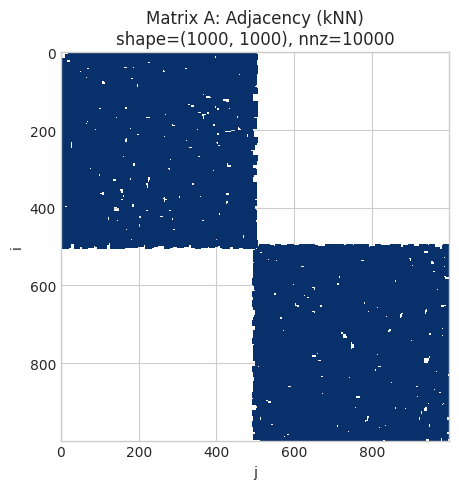

In [28]:
from sklearn.neighbors import kneighbors_graph

# Calculate kNN neighborhoods since affinity=’nearest_neighbor’
# N_NEIGHBORS is parameter for SpectralClustering

# A is the directed kNN adjacency: A[i,j] = 1 iff j is in i's k nearest neighbors, asymmetric in general
A = kneighbors_graph(X, n_neighbors=N_NEIGHBORS, mode="connectivity", include_self=False)

print(f"A shape: {A.shape}, nnz: {A.nnz}")

show_matrices(A, titles=["Matrix A: Adjacency (kNN)"], figsize=(5, 5), dot_size=18)

## Step 3 - Affinity Matrix: `W`
* Make `A` symmetric and undirected
* `W` = 0.5 * (A + A.T)
* `W`[i,j] = 1 mutual, 0.5 one-way, 0 disconnected.
* W is matrix of i to j (n x n) (index for each sample)
* W[i,j] = 1 if mutual neighbors, 0.5 if one-way, else 0
* white = 0 (disconnected)
* dark blue = 1 (mutual connection)
* light blue = 0.5 (one-way connection)

Affinity matrix W shape: (1000, 1000), nonzeros: 11878


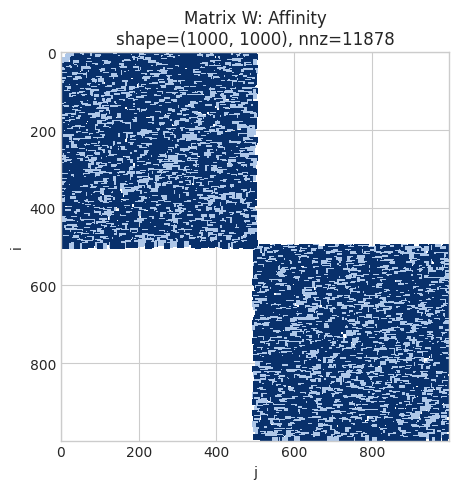

In [29]:
# W = n x n matrix. n = number of samples, or points from original data. 
# W[i,j] = edge weight between points i and j. Values are 0 (disconnected), 0.5 (one-way), or 1 (mutual kNN).
# Symmetrize A into W so the Laplacian is symmetric (required for real eigenvalues / orthogonal eigenvectors).

W = 0.5 * (A + A.T)

print(f"Affinity matrix W shape: {W.shape}, nonzeros: {W.nnz}")

show_matrices(W, titles=["Matrix W: Affinity"], figsize=(5, 5), dot_size=18)

##### Affinity Graph Plot

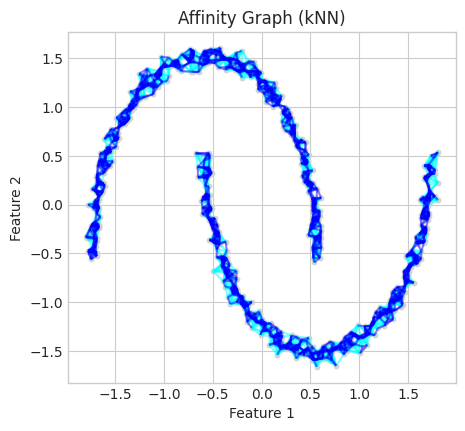

In [30]:
# The matrix created above: node/point/sample(i), node/point/sample(j), weighted edge: 0, 0.5, or 1
# Vectorized: pull only the upper-triangular nonzero edges from the (symmetrized) sparse affinity, 
# then draw each color group as a single LineCollection.

# W[i,j] == 1 means a mutual kNN edge; 0.5 means a one-way edge.
from matplotlib.collections import LineCollection
from scipy.sparse import triu

W_preview = 0.5 * (A + A.T)
W_upper = triu(W_preview, k=1).tocoo()
i_idx, j_idx, vals = W_upper.row, W_upper.col, W_upper.data
mutual = vals == 1
mutual_segs = np.stack([X[i_idx[mutual]],  X[j_idx[mutual]]],  axis=1)
uni_segs    = np.stack([X[i_idx[~mutual]], X[j_idx[~mutual]]], axis=1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], c="lightgray", s=10)
ax.add_collection(LineCollection(uni_segs,    colors="cyan", alpha=0.5))
ax.add_collection(LineCollection(mutual_segs, colors="blue", alpha=0.5))
ax.set_title("Affinity Graph (kNN)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_aspect("equal")
ax.autoscale_view()
plt.show()

## Step 4 - Degree Matrix: `D`
* `D` is an n×n diagonal matrix where diagonal values are sums from the row of `W`
* Each diagonal entry `D[i,i]` is the sum of row i of `W`. 
* It is the total edge weight attached to sample i (its "degree"). 
* All off-diagonal entries are 0. 
* Note `D` is built from `W`'s row sums; it is not a slice of `W`. 
* `W`'s own diagonal is zero (no self-edges)

Degree matrix D shape: (1000, 1000) (sparse diagonal)
First 10 degrees: [11.5 11.  11.  12.   7.5  8.5 12.  11.5  9.5 10.5]


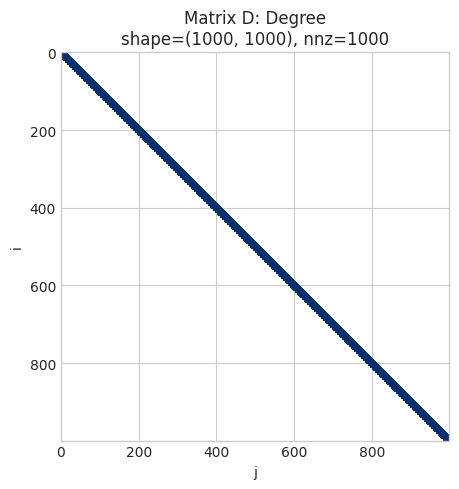

In [31]:
from scipy.sparse import diags

degrees = np.asarray(W.sum(axis=1)).ravel()
D = diags(degrees)

print(f"Degree matrix D shape: {D.shape} (sparse diagonal)")
print(f"First 10 degrees: {degrees[:10]}")

show_matrices(D, titles=["Matrix D: Degree"], figsize=(5, 5), dot_size=18)

## Step 5 - Normalized Symmetric Laplacian: `L`
* $$L = I - D^{-1/2} W D^{-1/2}$$

Normalized Laplacian L shape: (1000, 1000), nonzeros: 12878


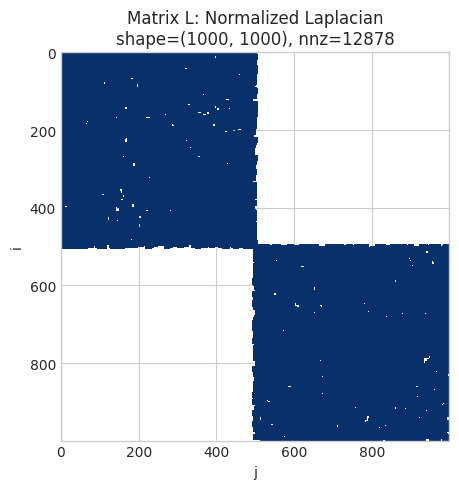

In [32]:
# eye = identity matrix
from scipy.sparse import eye

d_inv_sqrt = 1.0 / np.sqrt(degrees)
D_inv_sqrt = diags(d_inv_sqrt)

L = (eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt).tocsr()
print(f"Normalized Laplacian L shape: {L.shape}, nonzeros: {L.nnz}")

show_matrices(L, titles=["Matrix L: Normalized Laplacian"], figsize=(5, 5), dot_size=18)

## Step 6 - Find Eigenvectors
* The eigenvectors with smallest eigenvalues are the smoothest signals on the graph.
* They vary the least between connected samples.
* They naturally separate disconnected, or weakly connected samples
* 3Blue2Brown explainer: https://www.youtube.com/watch?v=PFDu9oVAE-g

In [33]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html
from scipy.sparse.linalg import eigsh

# eigsh returns only the k requested pairs but the order isn't guaranteed.
eigenvalues, eigenvectors = eigsh(L, k=N_CLUSTERS, sigma=0, which="LM")

print(f"Eigenvalues (bottom-{N_CLUSTERS}): {eigenvalues}")

Eigenvalues (bottom-2): [-2.75779399e-17 -2.23820962e-17]


## Step 7 - Sort Eigenvectors & Eigenvalues
* sort the eigenvalue/eigenvector pairs (λ₁, v₁), (λ₂, v₂) by the eigenvalue, ascending. 


In [34]:
eig_order = np.argsort(eigenvalues)
sorted_eigenvalues = eigenvalues[eig_order]
sorted_eigenvectors = eigenvectors[:, eig_order].T  # rows = eigenvectors, matching original layout

print(f"Sorted eigenvalues: {sorted_eigenvalues}")

Sorted eigenvalues: [-2.75779399e-17 -2.23820962e-17]


## Step 8 - Bottom-k Eigenvectors
* Keep k pairs corresponding to the smallest eigenvalues. These are the bottom-k eigenvectors
* The sparse eigsh call above already returned exactly the bottom-N_CLUSTERS eigenpairs.
* Multiplicity of the 0 eigenvalue equals the number of connected components in the graph.

In [35]:
k_pairs = list(zip(sorted_eigenvalues, sorted_eigenvectors))

print(f"Selected bottom-{N_CLUSTERS} eigenvalue/eigenvector pairs:")

for i, (λ, v) in enumerate(k_pairs):
    print(f"Pair {i+1}: Eigenvalue = {λ}, Eigenvector (first 5 values) = {v[:5]}")

Selected bottom-2 eigenvalue/eigenvector pairs:
Pair 1: Eigenvalue = -2.7577939931675947e-17, Eigenvector (first 5 values) = [-0.04795832 -0.04690416 -0.04690416 -0.04898979 -0.03872983]
Pair 2: Eigenvalue = -2.238209617643609e-17, Eigenvector (first 5 values) = [-9.06795765e-17 -9.50717956e-17 -7.96820104e-17 -9.03385073e-17
 -7.35309520e-17]


##### Visualize Eigenvectors

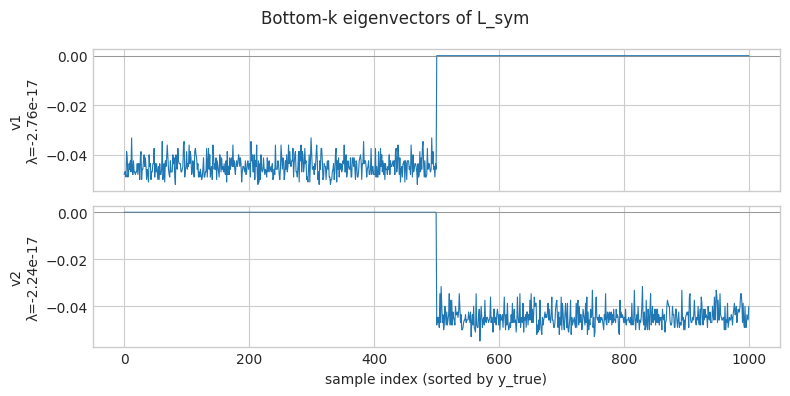

In [36]:
fig, axes = plt.subplots(N_CLUSTERS, 1, figsize=(8, 2 * N_CLUSTERS), sharex=True)
for ax, (λ, v), idx in zip(axes, k_pairs, range(N_CLUSTERS)):
    ax.plot(v, lw=0.8)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel(f"v{idx+1}\nλ={λ:.2e}")
axes[-1].set_xlabel("sample index (sorted by y_true)")
plt.suptitle("Bottom-k eigenvectors of L_sym")
plt.tight_layout()

## Step 9 - Embedding Matrix: `E`
* Stack bottom-k eigenvectors as columns to create the n×k embedding matrix `E`

In [37]:
embedding = np.column_stack([v for λ, v in k_pairs])

print(f"Embedding shape: {embedding.shape}")
print(f"First 5 rows of the embedding matrix:\n{embedding[:5]}")

Embedding shape: (1000, 2)
First 5 rows of the embedding matrix:
[[-4.79583152e-02 -9.06795765e-17]
 [-4.69041576e-02 -9.50717956e-17]
 [-4.69041576e-02 -7.96820104e-17]
 [-4.89897949e-02 -9.03385073e-17]
 [-3.87298335e-02 -7.35309520e-17]]


## Step 10 - Normalized Embedding Matrix: `E` Normalized
* Row-normalize each row in the n×k embedding matrix.
* Make each row’s distance = 1 (unit distance). 
* Example: row = [0.41, 0.02] → length √(0.41² + 0.02²) ≈ 0.4105 → divide through → [0.999, 0.049].
* Same direction, unit length. Row magnitude is mostly an artifact of node degree, not cluster identity. 
* The direction encodes the cluster.
* Normalizing keeps direction, removes magnitude which does not help identify clusters 

In [38]:
from sklearn.preprocessing import normalize
normalized_embedding = normalize(embedding, norm="l2")

print(f"Normalized embedding shape: {normalized_embedding.shape}")
print(f"First 5 rows of the normalized embedding matrix:\n{normalized_embedding[:5]}")

Normalized embedding shape: (1000, 2)
First 5 rows of the normalized embedding matrix:
[[-1.00000000e+00 -1.89079988e-15]
 [-1.00000000e+00 -2.02693749e-15]
 [-1.00000000e+00 -1.69882617e-15]
 [-1.00000000e+00 -1.84402706e-15]
 [-1.00000000e+00 -1.89856102e-15]]


## Step 11 - K-Means on Normalized Embedding Matrix `E`
* Run k-means on the rows in the normalized embedding matrix.
* Each row's label maps back to the original sample by row index
* Assign each sample to a cluster/moon

In [39]:
# Parameters used in SpectralClustering used below in manual steps:
# N_CLUSTERS, RANDOM_STATE, ASSIGN_LABELS

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE).fit(normalized_embedding)
labels = kmeans.labels_
print(f"Cluster labels for the first 10 samples: {labels[:10]}")
print(f"Cluster labels for the last  10 samples: {labels[-10:]}")

Cluster labels for the first 10 samples: [1 1 1 1 1 1 1 1 1 1]
Cluster labels for the last  10 samples: [0 0 0 0 0 0 0 0 0 0]


## Plot Spectral Clustering Results

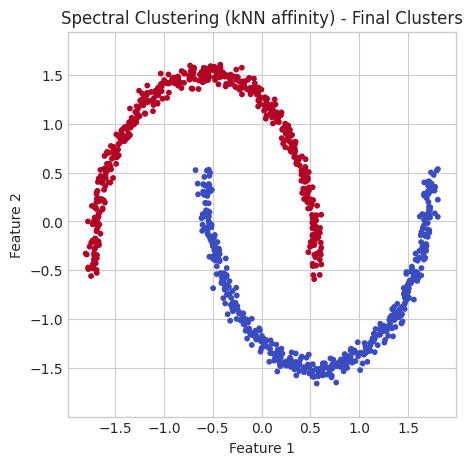

In [40]:
# Plot the clusters in the original data space, colored by the spectral clustering labels
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", s=10)
plt.title("Spectral Clustering (kNN affinity) - Final Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.show()  

---

## Scikit-Learn Spectral Clustering with NVIDIA cuML

##### Enable GPU acceleration for scikit-learn

In [42]:
%reload_ext cuml.accel

##### Run K-Means for comparison

In [43]:
# KMeans (will fail — convex assumption)
km = KMeans(n_clusters=N_CLUSTERS, n_init=N_NEIGHBORS, random_state=RANDOM_STATE).fit(X)

##### Scikit-learn Spectral Clustering

In [44]:
# Spectral clustering with kNN affinity (handles the manifold)

sc = SpectralClustering(
    n_clusters=N_CLUSTERS,
    affinity=AFFINITY,
    n_neighbors=N_NEIGHBORS,
    assign_labels=ASSIGN_LABELS,
    random_state=RANDOM_STATE,
).fit(X)

> Note the KMeans (middle) plot below has incorrectly labeled samples

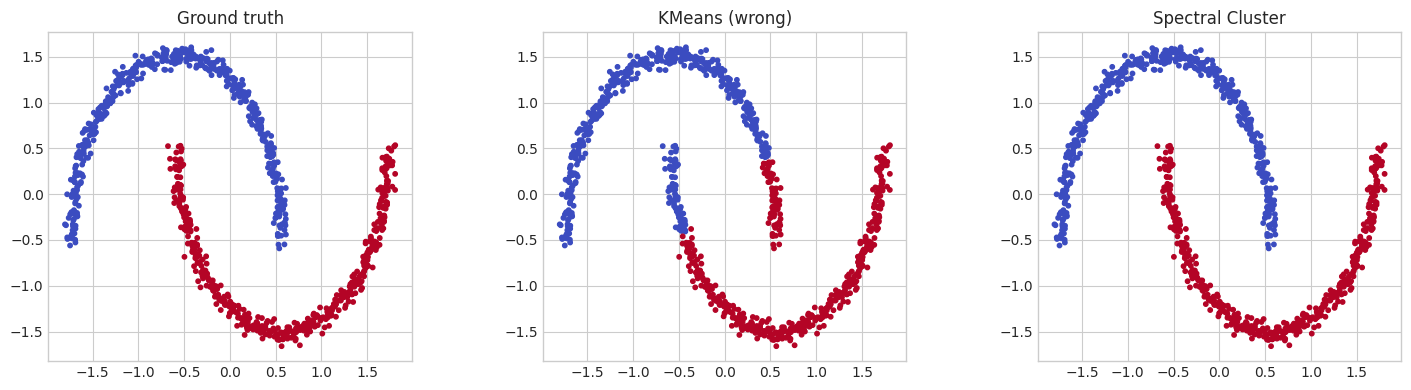

In [45]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, labels, title in zip(
    axes,
    [y_true, km.labels_, sc.labels_],
    ["Ground truth", "KMeans (wrong)", "Spectral Cluster"],
):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", s=10)
    ax.set_title(title)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Compare manual spectral clustering labels to sklearn's SpectralClustering output

In [46]:
# Cluster IDs are arbitrary (0/1 may be swapped), so:
#   - agreement is max(match, 1 - match) over raw label equality
#   - ARI is label-permutation invariant and is the standard metric
from sklearn.metrics import adjusted_rand_score

agreement = max((labels == sc.labels_).mean(), (labels == 1 - sc.labels_).mean())
ari = adjusted_rand_score(sc.labels_, labels)

print(f"Agreement with sklearn (best label alignment): {agreement:.4f}")
print(f"Adjusted Rand Index:                            {ari:.4f}")
print(f"Disagreeing samples: {int((1 - agreement) * len(labels))} / {len(labels)}")

Agreement with sklearn (best label alignment): 1.0000
Adjusted Rand Index:                            1.0000
Disagreeing samples: 0 / 1000


## Manual Spectral Clustering - Consolidated

In [47]:
import numpy as np
from scipy.sparse import eye
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from sklearn.datasets import make_moons
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering

# HIGHLIGHTNG PARAMETERS for Spectral Clustering used below in manual steps:
N_CLUSTERS=2
N_NEIGHBORS=10
RANDOM_STATE=42
# AFFINITY="nearest_neighbors"
# ASSIGN_LABELS="kmeans"

n = 1000

# Step 0 - Raw Data
X, y_true = make_moons(n_samples=n, noise=0.03, random_state=RANDOM_STATE)

# Step 1 - Standardize
X = StandardScaler().fit_transform(X)

# Step 2 - Adjacency Matrix
A = kneighbors_graph(X, n_neighbors=N_NEIGHBORS, mode="connectivity", include_self=False)

# Step 3 - Affinity Matrix
W = 0.5 * (A + A.T)

# Step 4 - Degree Matrix
degrees = np.asarray(W.sum(axis=1)).ravel()

# Step 5 - Normalize Symmetric Laplacian: L
d_inv_sqrt = 1.0 / np.sqrt(degrees)
D_inv_sqrt = diags(d_inv_sqrt)
L = (eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt).tocsr()

# Step 6 - Find Eigenvectors
eigenvalues, eigenvectors = eigsh(L, k=N_CLUSTERS, sigma=0, which="LM")

# Step 7 - Sort Eigenvectors & Eigenvalues
eig_order = np.argsort(eigenvalues)
sorted_eigenvalues = eigenvalues[eig_order]
sorted_eigenvectors = eigenvectors[:, eig_order].T  # rows = eigenvectors, matching original layout

# Step 8 - Bottom-K Eigenvectors
k_pairs = list(zip(sorted_eigenvalues, sorted_eigenvectors))

# Step 9 - Embedding Matrix: E
embedding = np.column_stack([v for λ, v in k_pairs])

# Step 10 - Normalize Embedding Matrix: E
normalized_embedding = normalize(embedding, norm="l2")

# Step 11 - K-Means on Normalized Embedding Matrix: E
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE).fit(normalized_embedding)
labels = kmeans.labels_

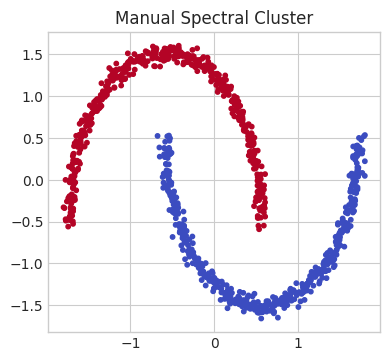

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", s=10)
ax.set_title("Manual Spectral Cluster")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()